# Pedestrian Collision Severity and Urban Greenspace Accessibility in London

## Preface

- GitHub Repository: [View link](https://github.com/christychoicc/DSSS_Coursework)

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

## 2. Research Question

[[ go back to the top ]](#Table-of-contents)

This analysis aims to answer the resarch question of: **What is the Relationship Between Levels of Pedestrian Collision Severity and Distance to the Nearest Urban Greenspace Access Point in London, Accounting for Road and Environmental Conditions?**

## 3. Data

[[ go back to the top ]](#Table-of-contents)

### 3.1. Load Packages
The below shows packages to install and import for data pre-processing, manipulation and running the analysis: 

In [1]:
# Install necessary packages for import next
# %pip install shap

In [2]:
# Packages for data processing and analysis

# --------------------------------- Data Wrangling and EDA -----------------------------------
import numpy as np                    # mathematical operations
import pandas as pd                   # data manipulation
import geopandas as gpd               # spatial data manipulation
import matplotlib.pyplot as plt       # visualisation

import warnings                       # supress warnings
warnings.filterwarnings('ignore')     # ignore warnings 


# ------------------------------------ Machine Learning --------------------------------------
from sklearn.ensemble import RandomForestClassifier        # Random Forest - Classification
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ----------------------------------- Accuracy Assessment -------------------------------------
from sklearn.metrics import r2_score                       # R squared 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score


# ----------------------------------- Model Interpretation -------------------------------------
#%pip install shap
import shap           # SHAP for model interpretation

# ------------------------------------- Notebook Settings --------------------------------------
random_state = 42                     # randomness
np.random.seed(random_state)          # random seed

### 3.2. Data Loading

In [3]:
# Load Collision 2024
collision = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-collision-2024.csv", low_memory=False)
print("Successfully Loaded Collision 2024 data...")

# Load Casualty 2024 
casualty = pd.read_csv("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/dft-road-casualty-statistics-casualty-2024.csv", low_memory=False)
print("Successfully Loaded Casualty 2024 data...")

# Load Green Space data
greenspace = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/OS-Open-Greenspace-GB/GB_AccessPoint.shp")
print("Successfully Loaded Greenspace data...")

# Load London LOSA boundary data
london_lsoa = gpd.read_file("https://raw.githubusercontent.com/christychoicc/DSSS_Coursework/main/london_LSOA_boundary/LSOA_2011_London_gen_MHW.shp")
print("Successfully Loaded London LSOA boundary data...")

Successfully Loaded Collision 2024 data...
Successfully Loaded Casualty 2024 data...
Successfully Loaded Greenspace data...
Successfully Loaded London LSOA boundary data...


In [4]:
# Data Inspection

# Inspect number of rows and columns for all dataset
print("Collision:", collision.shape)
print("Casualty:", casualty.shape)
print("Greenspace:", greenspace.shape)

# Inspect CRS for greenspace data
print("\nGreenspace CRS:", greenspace.crs)

# Inspect column names for all dataset
print("\nCollision Column names:\n")
print(collision.columns.tolist())
print("\nCasualty Column names:\n")
print(casualty.columns.tolist())
print("\nGreenspace Column names:\n")
print(greenspace.columns.tolist())

Collision: (100927, 44)
Casualty: (128272, 23)
Greenspace: (355296, 4)

Greenspace CRS: EPSG:27700

Collision Column names:

['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_

### 3.3. Data Pre-processing 

#### 3.3.1. Data Cleaning
##### Filter Road Safety Data (Collision and Casualty):

In [5]:
# Define a selection of needed column names
# Select needed columns for collision data
collision_cols = [    
    'collision_index', 'longitude', 'latitude', 'police_force',
    'speed_limit', 'road_type', 'junction_detail', 'junction_control',
    'pedestrian_crossing', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'urban_or_rural_area', 'date', 'day_of_week',
    'time', 'local_authority_district', 'lsoa_of_accident_location']

# Select neeeded columns for Casualty data
# casualty_severity and enhanced_casualty_severity is same thing but enhanced is more detailed, keep both first
casualty_cols = ["collision_index", "casualty_severity", 'casualty_type',
                 'pedestrian_location', 'pedestrian_movement']
# May need to use these columns? Keep first: 
# "enhanced_casualty_severity", "casualty_adjusted_severity_serious","casualty_adjusted_severity_slight", 
# 'age_of_casualty', 'sex_of_casualty', 'casualty_imd_decile'

# Filter to selected columns
collision_filtered = collision[collision_cols]
casualty_filtered = casualty[casualty_cols]
print(f"Filtered columns collision: {collision_filtered.shape}")
print(f"Filtered columns casualty: {casualty_filtered.shape}")

Filtered columns collision: (100927, 18)
Filtered columns casualty: (128272, 5)


In [6]:
# Filter collision data to London only
# This uses the police_force column to select London, 
# where 1 = Metropolitan (excluding City of London) and 48 = City of London
london_collision = collision_filtered[collision_filtered['police_force'].isin([1, 48])]
print("London only collisions:", london_collision.shape)

# Filter casualty data to pedestrian only
# where casualty_type = 0 = pedestrian
pedestrian_casualty = casualty_filtered[casualty_filtered['casualty_type'] == 0]
print("Pedestrian only casualties:", pedestrian_casualty.shape)

# Using pedestrian casualty to filter pedestrian involved collisions
# Filter collisions index that involves pedestrian only
pedestrian_collision_index = pedestrian_casualty['collision_index'].unique()

# Filter to London pedestrian collisions only
london_pedestrian_collision = london_collision[london_collision['collision_index'].isin(pedestrian_collision_index)].copy()
print("London Pedestrian only collisions: ", london_pedestrian_collision.shape)

London only collisions: (21000, 18)
Pedestrian only casualties: (19176, 5)
London Pedestrian only collisions:  (4305, 18)


In [7]:
# For each collision, create a new variable of severity_binary
# Original data provided casualty_severity: 1 = Fatal, 2 = Serious, 3 = Slight
# Create severity_binary: Fatal/ Serious = 1, Slight = 0 
def is_fatalserious_or_slight(severity_values):
    return 1 if severity_values.min() <= 2 else 0

# Merge data
casualty_details = (
    pedestrian_casualty
    .groupby('collision_index')
    .agg(severity_binary=('casualty_severity', is_fatalserious_or_slight),
        pedestrian_location=('pedestrian_location', 'first'))
    .reset_index())
df_merged = london_pedestrian_collision.merge(casualty_details, on='collision_index', how='inner')

# Create a hour column
df_merged['hour'] = pd.to_datetime(df_merged['time'], format='%H:%M').dt.hour

print("Merged data:", df_merged.shape)
print("\nColumn names: \n")
print(df_merged.columns.tolist())

Merged data: (4305, 21)

Column names: 

['collision_index', 'longitude', 'latitude', 'police_force', 'speed_limit', 'road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'date', 'day_of_week', 'time', 'local_authority_district', 'lsoa_of_accident_location', 'severity_binary', 'pedestrian_location', 'hour']


##### Filter OS Open Greenspace Access Point Data (Greenspace): 

In [8]:
# Filter Greenspace data to London only
# Using a rough London bounding box 
greenspace_london = greenspace.cx[503000:563000, 155000:202000].copy()
print("London greenspace access points:", greenspace_london.shape)

London greenspace access points: (30115, 4)


In [9]:
# Transform geometry column's point(x y z) into normal point(x y) only
# Code derived from Claude AI
from shapely.geometry import Point

greenspace_london['geometry'] = greenspace_london['geometry'].apply(
    lambda g: Point(g.x, g.y)  # drops Z, keeps X and Y only
)

# Check
#print(greenspace_london.geometry.iloc[0])

In [10]:
# Join london_pedestrian_collision and london_greenspace

# Convert collision df to GeoDataFrame
gdf_collisions = gpd.GeoDataFrame(
    df_merged,
    geometry=gpd.points_from_xy(df_merged['longitude'], 
                                df_merged['latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:27700')  # reproject to match greenspace CRS

# Calculate distance to the nearest greenspace access point
join = gpd.sjoin_nearest(
    gdf_collisions,
    greenspace_london[['geometry']],
    how='left',
    distance_col='green_access_distance'
)

# Add distance to df
df_merged['green_access_distance'] = join['green_access_distance'].values

In [11]:
# Extract needed columns
clean_cols = [
    'collision_index', 'longitude', 'latitude',
    'speed_limit', 'road_type', 'junction_detail', 'junction_control',
    'pedestrian_crossing', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'urban_or_rural_area', 'day_of_week',
    'date', 'hour', 'local_authority_district', 'lsoa_of_accident_location',
    'pedestrian_location','green_access_distance', 'severity_binary'
]

# Cleaned df: 
df_merged_joined = df_merged[clean_cols].copy()

In [12]:
# Check (undo the following # to run the code)
#print("df_merged_joined shape: ", df_merged_joined.shape)
#print("Columns: ", df_merged_joined.columns.tolist())
#print("Missing values: ", df_merged_joined.isnull().sum())
#print("Severity count: ", df_merged_joined['severity_binary'].value_counts())
#print("Green access distance: ", df_merged_joined['green_access_distance'].describe())

In [13]:
# Check if there is any missing values across all columns: (undo the following # to run the code)

# Check value counts for all categorical columns to spot -1 and unknowns
#categorical_cols = [
#    'speed_limit', 'road_type', 'junction_detail', 'junction_control',
#    'pedestrian_crossing', 'light_conditions', 'weather_conditions',
#    'road_surface_conditions', 'urban_or_rural_area', 'day_of_week',
#    'pedestrian_location', 'pedestrian_movement'
#]

#for col in categorical_cols:
#    print(f"\n{col}:")
#    print(df_clean[col].value_counts().sort_index())

#### 3.3.2. Evaluation of missing, unknown or others data
|Variable|Any Missing/ Unknown Data?|Description|Action|
|---|---|---|---|
|speed_limit|No|NA|NA|
|road_type|Yes| 9 (349 rows of unknown)|Drop the unknown rows|
|junction_detail|Yes|-1 (353 rows of missing)|Drop the missing rows|
|junction_control|Yes|-1 (1039 rows of missing); 9 (243 rows of unknown)|Drop all missing and unknown rows|
|light_conditions|No|NA|NA|
|weather_conditions|Yes|8 (239 rows of others); 9 (303 rows of unknown)|Drop all others and unknown rows|
|road_surface_conditions|Yes|9 (212 rows of unknown)|Drop the unkown rows|
|urban_or_rural_area|No|NA|NA|
|pedestrian_crossing|Yes|99 (312 rows of unknown)|Drop the unknown rows|
|pedestrian_location|Yes|10 (415 rows of unknown)|Drop the unknown rows|

In [14]:
# Drop rows with missing/ unknown values
initial_rows = len(df_merged_joined)

df_clean = df_merged_joined[
    (df_merged_joined['road_type'] != 9) &
    (df_merged_joined['junction_detail'] != -1) &
    (df_merged_joined['junction_control'].isin([-1, 9]) == False) &
    (df_merged_joined['weather_conditions'].isin([8, 9]) == False) &
    (df_merged_joined['road_surface_conditions'] != 9) &
    (df_merged_joined['pedestrian_crossing'] != 99) &
    (df_merged_joined['pedestrian_location'] != 10)
].copy()

print(f"Rows before dropping missing/ unknown/ others: {initial_rows}")
print(f"Rows after dropping missing/ unknown/ others:  {len(df_clean)}")
print(f"Rows removed: {initial_rows - len(df_clean)} ({(initial_rows - len(df_clean))/initial_rows*100:.1f}%)")
print(f"\nSeverity Binary count:\n{df_clean['severity_binary'].value_counts()}")

Rows before dropping missing/ unknown/ others: 4305
Rows after dropping missing/ unknown/ others:  2223
Rows removed: 2082 (48.4%)

Severity Binary count:
severity_binary
0    1597
1     626
Name: count, dtype: int64


In [15]:
# Check the distribution of data for assigning suitable bands
df_clean['green_access_distance'].describe()

count    2223.000000
mean      165.201238
std       113.963680
min         2.945525
25%        83.815738
50%       147.363522
75%       221.734119
max      1331.872055
Name: green_access_distance, dtype: float64

In [16]:
# Calculate suitable band ranges and create a new variable column
df_clean['green_distance_band'] = pd.cut(
    df_clean['green_access_distance'],
    # < 100 below 25 percentile
    # 100-200 median 
    # 200-300 around 75 percentile
    # > 300 as furthest range
    bins=[0, 100, 200, 300, float('inf')],
    labels=['0-100m', '100-200m', '200-300m', '300m+']
)
bands = df_clean.groupby('green_distance_band')['severity_binary'].agg(['mean', 'count'])
bands.columns = ['Severity Rate', 'Count']
print(bands)

                     Severity Rate  Count
green_distance_band                      
0-100m                    0.294630    689
100-200m                  0.288889    855
200-300m                  0.247166    441
300m+                     0.281513    238


In [17]:
# Check columns
print(df_clean.columns.tolist())
print(df_clean['green_distance_band'].value_counts())

['collision_index', 'longitude', 'latitude', 'speed_limit', 'road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'day_of_week', 'date', 'hour', 'local_authority_district', 'lsoa_of_accident_location', 'pedestrian_location', 'green_access_distance', 'severity_binary', 'green_distance_band']
green_distance_band
100-200m    855
0-100m      689
200-300m    441
300m+       238
Name: count, dtype: int64


#### 3.3.3. Table of Variables
| Variable Name | Description | Data Type | Purpose |
|---|---|---|---|
|severity_binary |1 = Fatal/ Serious, 0 = Slight |Binary |Target |
|green_access_distance |Distance to the nearest greenspace access point (meters) |Numeric | |
|green_distance_band||||
|speed_limit | |Categorical | |
|road_type | |Categorical | |
|junction_detail | |Categorical | |
|junction_control | |Categorical | |
|light_conditions | |Categorical | |
|weather_conditions | |Categorical | |
|road_surface_conditions | |Categorical | |
|urban_or_rural_area | |Categorical | |
|day_of_week| |Categorical | |
|pedestrian_location | |Categorical | |
|pedestrian_crossing | |Categorical | |
|date| |Date | |
|hour | |Numeric | |
|collision_id||ID||
|longitute||Geometry||
|latitude||Geometry||
|local_authority_district | |Categorical | |
|lsoa_of_accident_location | |ID | |

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

### 4.1. Exploratory Analysis

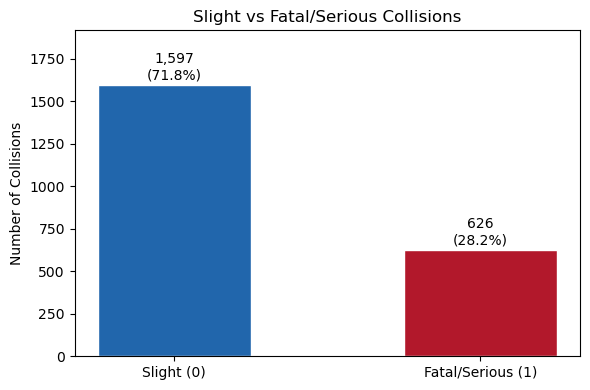

In [18]:
# Slight vs Fatal/ Severity
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_clean['severity_binary'].value_counts().sort_index()
bars = ax.bar(['Slight (0)', 'Fatal/Serious (1)'], counts.values,
              color=['#2166AC', '#B2182B'], edgecolor='white', width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{count:,}\n({count/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Slight vs Fatal/Serious Collisions',
             fontsize=12)
ax.set_ylabel('Number of Collisions')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

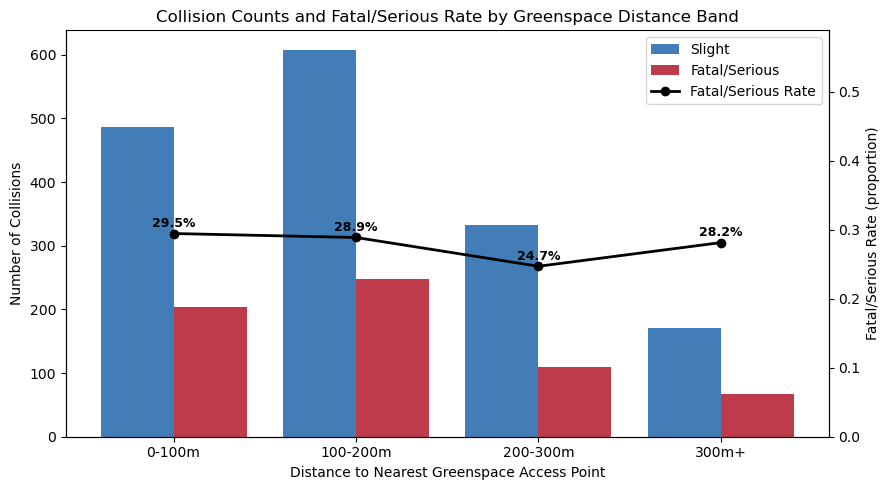

                     Severity Rate  Count
green_distance_band                      
0-100m                    0.294630    689
100-200m                  0.288889    855
200-300m                  0.247166    441
300m+                     0.281513    238


In [19]:
# ── Figure 4: Collision Count by Distance Band (split by severity) ───
band_detail = (df_clean.groupby(['green_distance_band', 'severity_binary'], observed=True)
               .size()
               .reset_index(name='count'))

slight_counts    = band_detail[band_detail['severity_binary'] == 0].set_index('green_distance_band')['count']
serious_counts   = band_detail[band_detail['severity_binary'] == 1].set_index('green_distance_band')['count']

# Compute severity rate per band for annotation
band_summary = bands.rename(columns={'Severity Rate': 'severity_rate', 'Count': 'total'})

bands_order = ['0-100m', '100-200m', '200-300m', '300m+']
x = range(len(bands_order))
width = 0.4

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.bar([i - width/2 for i in x],
        [slight_counts.get(b, 0) for b in bands_order],
        width=width, color='#2166AC', label='Slight', alpha=0.85)
ax1.bar([i + width/2 for i in x],
        [serious_counts.get(b, 0) for b in bands_order],
        width=width, color='#B2182B', label='Fatal/Serious', alpha=0.85)

# Overlay severity rate as a line
severity_rates = [band_summary.loc[b, 'severity_rate'] if b in band_summary.index else 0 for b in bands_order]
ax2.plot(list(x), severity_rates, color='black', linewidth=2, marker='o',
         markersize=6, label='Fatal/Serious Rate', zorder=5)
for i, r in enumerate(severity_rates):
    ax2.text(i, r + 0.005, f'{r:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(list(x))
ax1.set_xticklabels(bands_order)
ax1.set_xlabel('Distance to Nearest Greenspace Access Point')
ax1.set_ylabel('Number of Collisions')
ax2.set_ylabel('Fatal/Serious Rate (proportion)', color='black')
ax2.set_ylim(0, max(severity_rates) * 2)
ax1.set_title('Collision Counts and Fatal/Serious Rate by Greenspace Distance Band',
              fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.show()

print(bands)

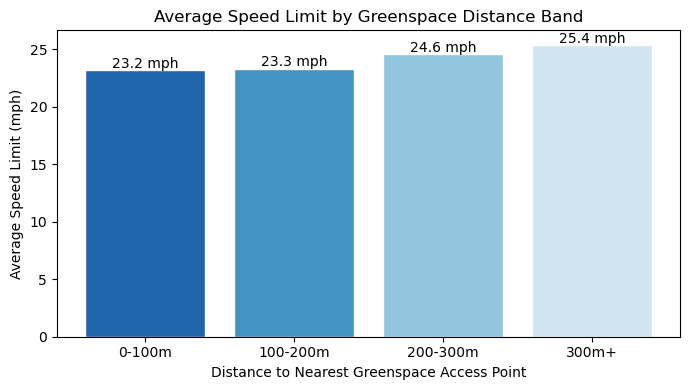

In [20]:
# Speed limit by greenspace distance band
speed_band = df_clean.groupby('green_distance_band', observed=True)['speed_limit'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(speed_band.index, speed_band.values,
       color=['#2166AC', '#4393C3', '#92C5DE', '#D1E5F0'],
       edgecolor='white')
for i, (band, val) in enumerate(speed_band.items()):
    ax.text(i, val + 0.2, f'{val:.1f} mph', ha='center', fontsize=10)
ax.set_title('Average Speed Limit by Greenspace Distance Band',
             fontsize=12)
ax.set_xlabel('Distance to Nearest Greenspace Access Point')
ax.set_ylabel('Average Speed Limit (mph)')
plt.tight_layout()
plt.show()

Average speed limits are lower closer to greenspace access points. This presents a potential confounding relationship, where a closer greenspace may associate with lower severity through due to lower speed limits, not the greenspace itself. Speed limit is therefore included as a covariate in both the Random Forest classification and Logistic Regression model, ensuring the greenspace related severity association is assessed conditionally rather than bivariately.

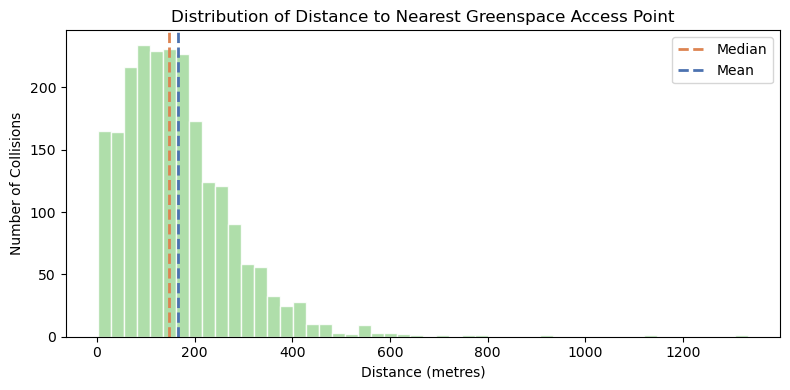

In [21]:
# Distribution of distance to greenspace
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_clean['green_access_distance'], bins=50,
        color='#A1D99B', edgecolor='white', alpha=0.85)

# Removed the calculated numbers from the label
ax.axvline(df_clean['green_access_distance'].median(), color='#DD8452',
           linewidth=2, linestyle='--',
           label="Median")

# Removed the calculated numbers from the label
ax.axvline(df_clean['green_access_distance'].mean(), color='#4C72B0',
           linewidth=2, linestyle='--',
           label="Mean")

ax.set_title('Distribution of Distance to Nearest Greenspace Access Point',
             fontsize=12)
ax.set_xlabel('Distance (metres)')
ax.set_ylabel('Number of Collisions')
ax.legend()
plt.tight_layout()
plt.show()

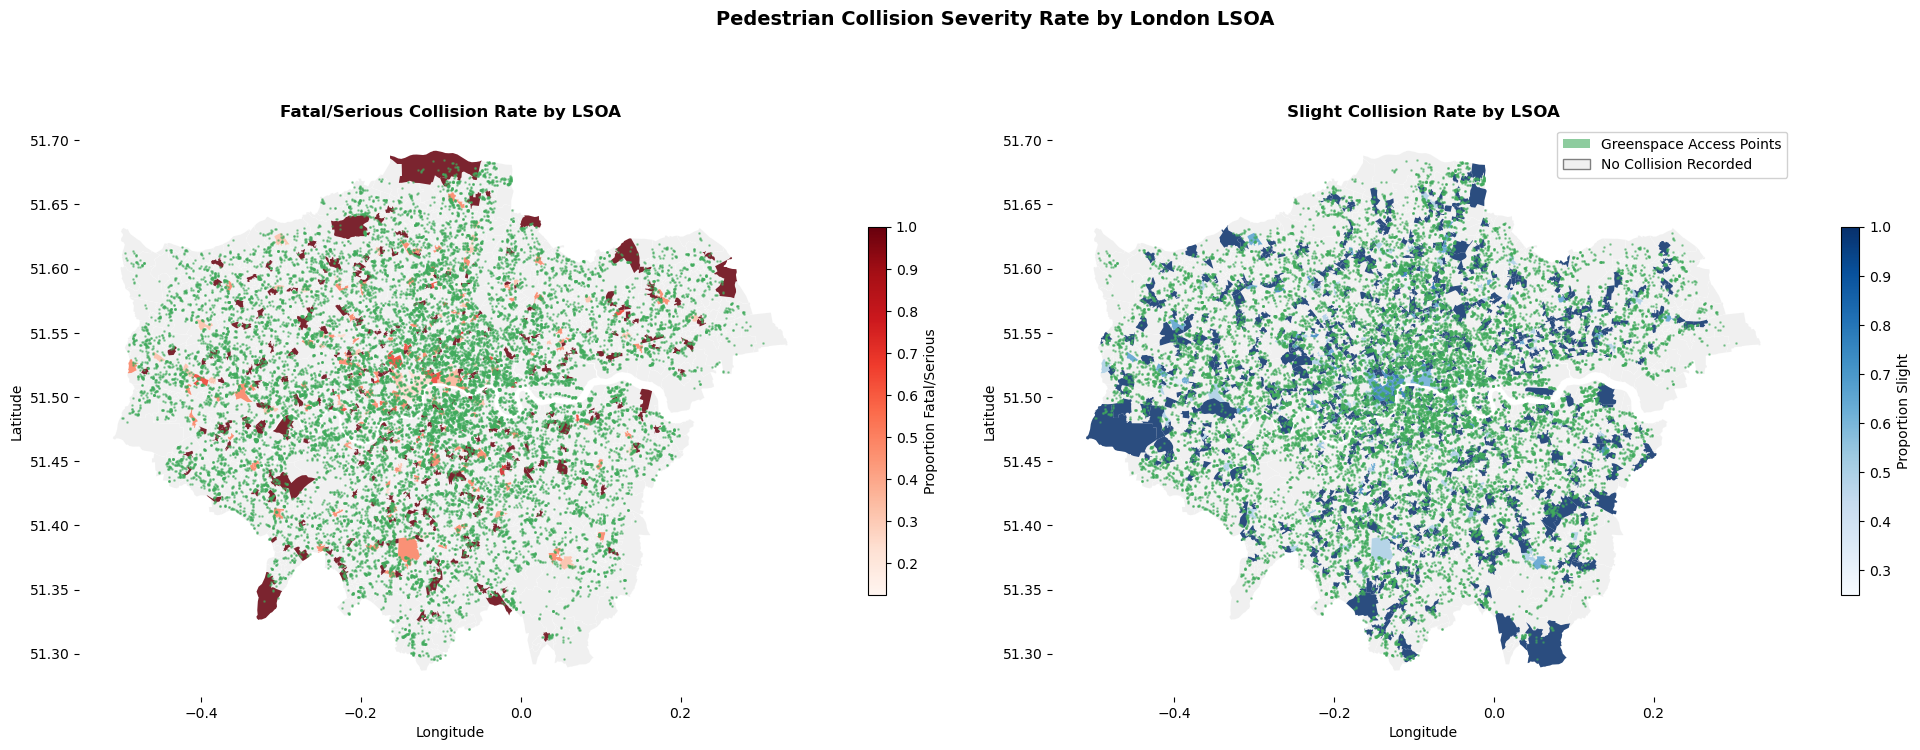

In [22]:
# Ensure projection is 4326
london_lsoa = london_lsoa.to_crs('EPSG:4326')

# Clip greenspace to london_lsoa boundary
greenspace_4326 = greenspace_london.to_crs('EPSG:4326')
greenspace_clipped = gpd.clip(greenspace_4326, london_lsoa)

# Calculate fatal/serious rate per LSOA
fatal_count = (df_clean[df_clean['severity_binary'] == 1]
               .groupby('lsoa_of_accident_location').size())
total_count = (df_clean.groupby('lsoa_of_accident_location').size())
rate_fs = (fatal_count / total_count).reset_index()
rate_fs.columns = ['LSOA11CD', 'severity_rate']
lsoa_fs = london_lsoa.merge(rate_fs, on='LSOA11CD', how='left')

# Calculate slight rate per LSOA
slight_count = (df_clean[df_clean['severity_binary'] == 0]
                .groupby('lsoa_of_accident_location').size())
rate_sl = (slight_count / total_count).reset_index()
rate_sl.columns = ['LSOA11CD', 'slight_rate']
lsoa_sl = london_lsoa.merge(rate_sl, on='LSOA11CD', how='left')

# Plot map
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left side — Fatal/Serious
london_lsoa.plot(ax=axes[0], color='#F0F0F0', edgecolor='white', linewidth=0.1)
lsoa_fs[lsoa_fs['severity_rate'].notna()].plot(
    ax=axes[0], column='severity_rate', cmap='Reds',
    edgecolor='none', alpha=0.85, legend=True,
    legend_kwds={'label': 'Proportion Fatal/Serious',
                 'orientation': 'vertical', 'shrink': 0.5}
)
greenspace_clipped.plot(ax=axes[0], color='#41AB5D', markersize=0.8, alpha=0.5)
axes[0].set_title('Fatal/Serious Collision Rate by LSOA', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].spines[['top','right','left','bottom']].set_visible(False)

# Right side — Slight
london_lsoa.plot(ax=axes[1], color='#F0F0F0', edgecolor='white', linewidth=0.1)
lsoa_sl[lsoa_sl['slight_rate'].notna()].plot(
    ax=axes[1], column='slight_rate', cmap='Blues',
    edgecolor='none', alpha=0.85, legend=True,
    legend_kwds={'label': 'Proportion Slight',
                 'orientation': 'vertical', 'shrink': 0.5}
)
greenspace_clipped.plot(ax=axes[1], color='#41AB5D', markersize=0.8, alpha=0.5)
axes[1].set_title('Slight Collision Rate by LSOA', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].spines[['top','right','left','bottom']].set_visible(False)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#41AB5D', alpha=0.6, label='Greenspace Access Points'),
    Patch(facecolor='#F0F0F0', edgecolor='grey', label='No Collision Recorded')
], loc='upper right', framealpha=0.9)

fig.suptitle('Pedestrian Collision Severity Rate by London LSOA',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2. Random Forest Classification

In [23]:
# Prepare data for modelling 
feature_cols = [
    'green_access_distance', 'speed_limit', 'road_type',
    'junction_detail', 'junction_control', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week', 'hour', 'pedestrian_location'
]

X = df_clean[feature_cols].copy()
y = df_clean['severity_binary'].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Severity rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

param_grid = {
    'max_depth':        [None, 5, 10, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf':  [1, 2, 4]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    return_train_score=True
)
grid.fit(X_train, y_train)

# Print best hyperparameters and best CV recall
print("Best hyperparameters:", grid.best_params_)
print(f"Best CV recall: {grid.best_score_:.3f}")

# Retrain with optimal hyperparameters
best_params = grid.best_params_
best_model = RandomForestClassifier(class_weight='balanced', random_state=42, **best_params)
best_model.fit(X_train, y_train)

# Recall on training and testing data
train_recall = recall_score(y_train, best_model.predict(X_train))
print(f"Train recall: {train_recall:.3f}")
test_recall = recall_score(y_test, best_model.predict(X_test))
print(f"Test recall: {test_recall:.3f}")

# Accuracy on training and testing data
train_accuracy = accuracy_score(y_train, best_model.predict(X_train))
print(f"Train accuracy: {train_accuracy:.3f}")
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))
print(f"Test accuracy: {test_accuracy:.3f}")

# Store the recall of CV, train, and test in a dictionary
rf_clf_results = {
    'CV_Recall':      grid.best_score_,
    'Train_Recall':   train_recall,
    'Test_Recall':    test_recall,
    'Train_Accuracy': train_accuracy,
    'Test_Accuracy':  test_accuracy
}

Train: 1778 rows | Test: 445 rows
Severity rate — train: 28.18% | test: 28.09%
Best hyperparameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV recall: 0.421
Train recall: 0.619
Test recall: 0.456
Train accuracy: 0.705
Test accuracy: 0.602


Accuracy:  0.602
Precision: 0.343
Recall:    0.456
F1-score:  0.392
ROC-AUC : 0.572
PR-AUC  : 0.328
               precision    recall  f1-score   support

       Slight       0.76      0.66      0.70       320
Fatal/Serious       0.34      0.46      0.39       125

     accuracy                           0.60       445
    macro avg       0.55      0.56      0.55       445
 weighted avg       0.64      0.60      0.62       445



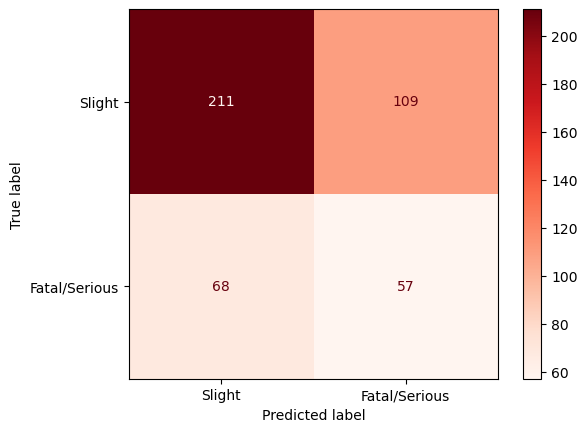

In [24]:
# Evaluate model performance on testing set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy:  {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')
print(f'F1-score:  {f1:.3f}')
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.3f}")      # RF
print(f"PR-AUC  : {average_precision_score(y_test, y_prob):.3f}")

# Print classification report
print(classification_report(y_test, y_pred, target_names=['Slight', 'Fatal/Serious']))

# Print confusion matrix
ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                       display_labels=['Slight', 'Fatal/Serious']).plot(cmap='Reds')

### 4.3. SHAP Model Interpretation

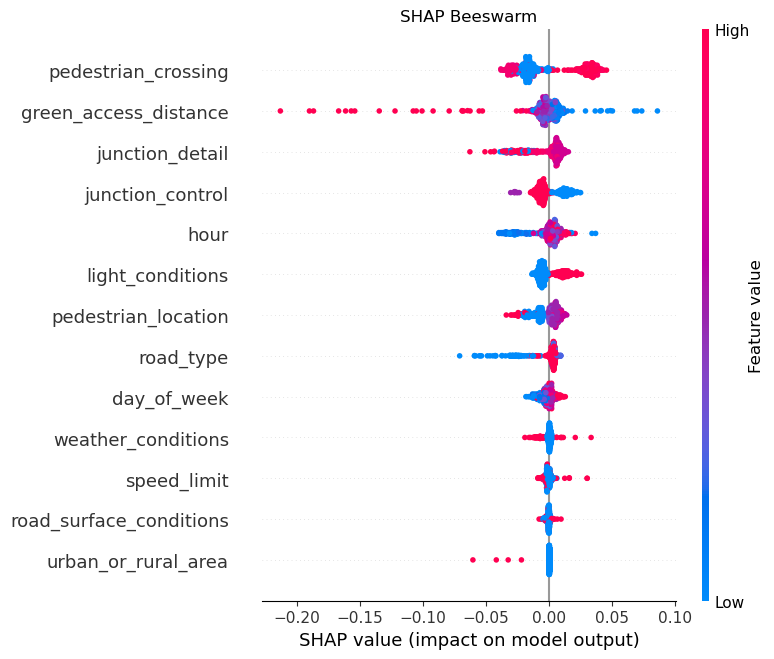

In [25]:
# Sample test set for speed
X_shap = X_test.sample(n=min(500, len(X_test)), random_state=42)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer(X_shap)   # returns Explanation object

shap.plots.beeswarm(shap_values[:, :, 1], max_display=15, show=False)
plt.title('SHAP Beeswarm', fontsize=12)
plt.tight_layout()
plt.show()

### 4.4. Logistic Regression

##### Logistic Regression as Neural Net Equation (Week 5 Lecture Slide)
$$y = \sigma(Wx + b)$$

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Logistic Regression Performance
               precision    recall  f1-score   support

       Slight       0.76      0.52      0.62       320
Fatal/Serious       0.32      0.58      0.41       125

     accuracy                           0.53       445
    macro avg       0.54      0.55      0.51       445
 weighted avg       0.63      0.53      0.56       445

ROC-AUC : 0.571
PR-AUC  : 0.323

green_access_distance coefficient: -0.1079
Direction: Negative — closer to greenspace = higher severity risk


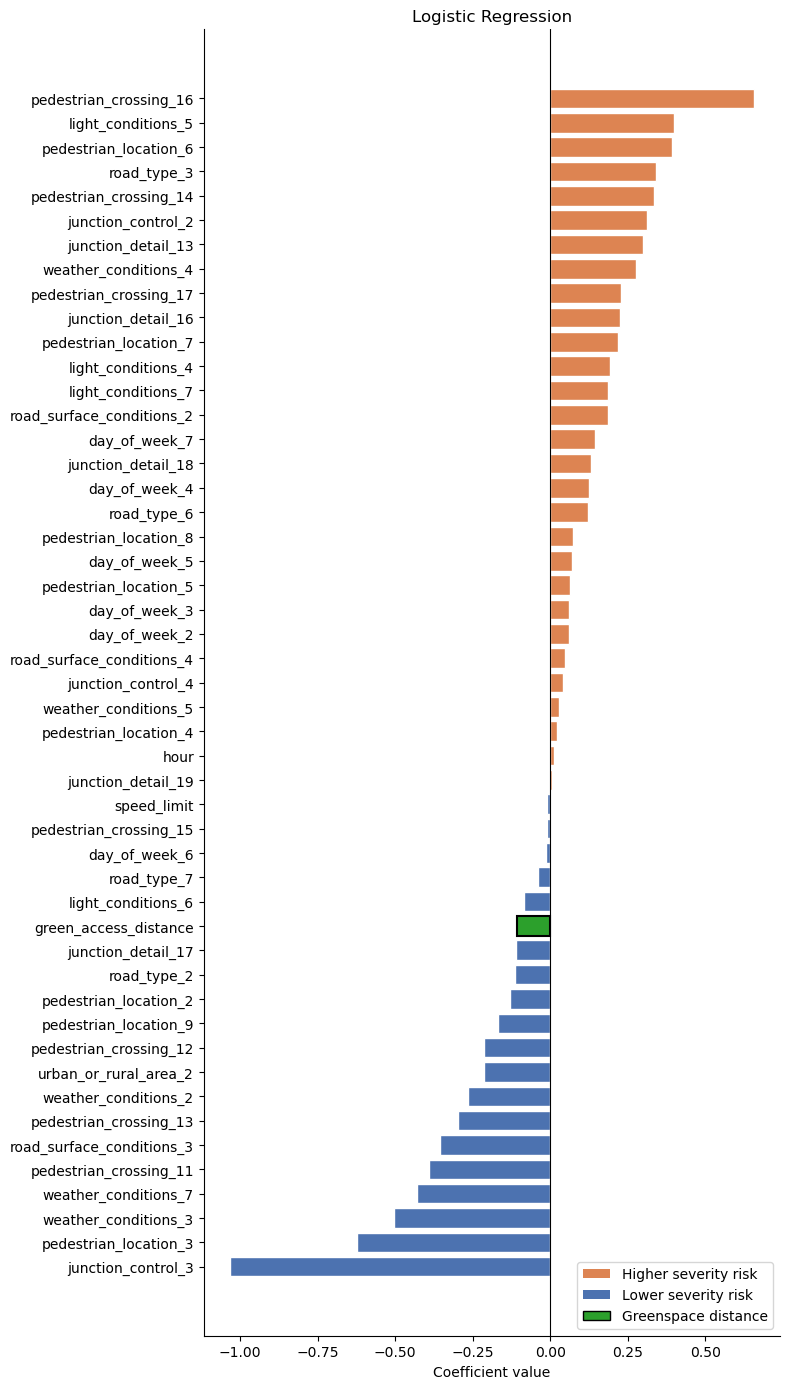

In [26]:
# One-hot encode categoricals
cat_cols = [
    'road_type', 'junction_detail', 'junction_control', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week', 'pedestrian_location'
]
num_cols = ['green_access_distance', 'speed_limit', 'hour']

# One-hot encoding
X_lr = pd.get_dummies(df_clean[feature_cols], columns=cat_cols, drop_first=True)
y_lr = df_clean['severity_binary'].copy()

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

# Scale numeric features only
scaler = StandardScaler()
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols]  = scaler.transform(X_test_lr[num_cols])

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_lr, y_train_lr)

y_pred_lr = lr.predict(X_test_lr)
y_prob_lr = lr.predict_proba(X_test_lr)[:, 1]

print("Logistic Regression Performance")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Slight', 'Fatal/Serious']))
print(f"ROC-AUC : {roc_auc_score(y_test_lr, y_prob_lr):.3f}")
print(f"PR-AUC  : {average_precision_score(y_test_lr, y_prob_lr):.3f}")

coef_df = pd.DataFrame({
    'feature':     X_train_lr.columns,
    'coefficient': lr.coef_[0]
})
green_coef = coef_df.loc[coef_df['feature'] == 'green_access_distance', 'coefficient'].values[0]
print(f"\ngreen_access_distance coefficient: {green_coef:.4f}")
print("Direction:", "Positive — further from greenspace = higher severity risk"
      if green_coef > 0 else "Negative — closer to greenspace = higher severity risk")

# All coefficients
all_coef = (coef_df.assign(abs_coef=coef_df['coefficient'].abs())
            .sort_values('coefficient'))

fig, ax = plt.subplots(figsize=(8, 14))

colors = ['#DD8452' if c > 0 else '#4C72B0' for c in all_coef['coefficient']]
bars = ax.barh(all_coef['feature'], all_coef['coefficient'],
               color=colors, edgecolor='white')

# Highlight greenspace bar in green
for bar, feat in zip(bars, all_coef['feature']):
    if feat == 'green_access_distance':
        bar.set_color('#2CA02C')
        bar.set_edgecolor('black')
        bar.set_linewidth(1.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression',
             fontsize=12)
ax.set_xlabel('Coefficient value')
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#DD8452', label='Higher severity risk'),
    Patch(facecolor='#4C72B0', label='Lower severity risk'),
    Patch(facecolor='#2CA02C', edgecolor='black', label='Greenspace distance')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [27]:
# Print greenspace coefficient directly
green_row = coef_df[coef_df['feature'] == 'green_access_distance']
print(green_row)
print(f"\nRank of green_access_distance by absolute coefficient: "
      f"{(coef_df['coefficient'].abs().rank(ascending=False)
      .loc[coef_df['feature'] == 'green_access_distance'].values[0]):.0f} "
      f"out of {len(coef_df)}")

                 feature  coefficient
0  green_access_distance    -0.107883

Rank of green_access_distance by absolute coefficient: 33 out of 49


*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

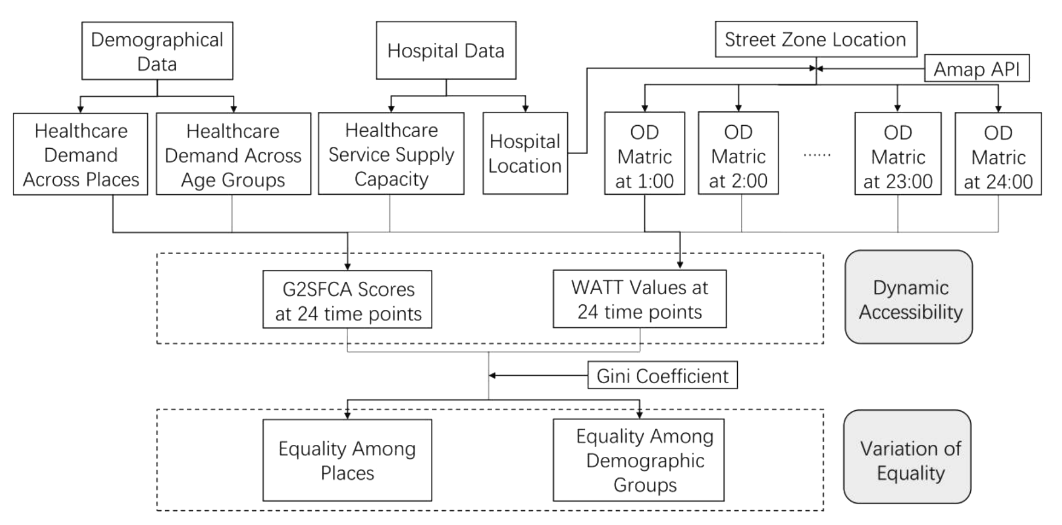

## 5. Results and discussion

[[ go back to the top ]](#Table-of-contents)

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

## 7. References

[[ go back to the top ]](#Table-of-contents)